In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import community as community_louvain
import joblib
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.append('D:/Projects/fraud-detection-shap-aws')
from utils.config_loader import load_config

# Load config and full dataset
config = load_config('D:/Projects/fraud-detection-shap-aws/configs/creditcard_config.json')
df = pd.read_csv('D:/Projects/fraud-detection-shap-aws/data/processed/creditcard_processed.csv')

# Load saved model and test data
xgb_model = joblib.load('D:/Projects/fraud-detection-shap-aws/models/xgb_fraud.pkl')
X_test, y_test = joblib.load('D:/Projects/fraud-detection-shap-aws/models/test_data.pkl')

print(f" Dataset loaded     : {df.shape}")
print(f" XGBoost loaded     : ready")
print(f" Test data loaded   : {X_test.shape}")
print(f" Fraud in test      : {y_test.sum()}")
print(f"\nReady for Day 6 — Advanced Detection")

Config loaded: Credit Card Fraud
 Dataset loaded     : (284807, 31)
 XGBoost loaded     : ready
 Test data loaded   : (56962, 30)
 Fraud in test      : 98

Ready for Day 6 — Advanced Detection


In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("="*55)
print("PART 1 — BEHAVIOURAL PROFILING")
print("="*55)
print("\nStep 1: Creating pseudo-user clusters...")
print("(Real dataset has no user IDs — we cluster similar")
print(" transaction patterns to simulate user behaviour)\n")

# Use key behavioural features
behavioural_features = ['Amount_Scaled', 'Time_Scaled', 'V1', 'V2', 'V3', 'V4']
X_behaviour = df[behavioural_features].copy()

# Create 1000 pseudo users via KMeans
kmeans = KMeans(n_clusters=1000, random_state=42, n_init=10)
df['user_cluster'] = kmeans.fit_predict(X_behaviour)

print(f" Created 1000 pseudo-user clusters")
print(f" Avg transactions per user : {len(df)/1000:.1f}")
print(f" User ID sample : {df['user_cluster'].head(5).values}")

PART 1 — BEHAVIOURAL PROFILING

Step 1: Creating pseudo-user clusters...
(Real dataset has no user IDs — we cluster similar
 transaction patterns to simulate user behaviour)

 Created 1000 pseudo-user clusters
 Avg transactions per user : 284.8
 User ID sample : [103 700 135 656 639]


In [5]:
print("Building behavioural baseline per user cluster...")

# Calculate baseline statistics per cluster
# This is what "normal" looks like for each user type
cluster_baseline = df.groupby('user_cluster').agg(
    avg_amount        = ('Amount_Scaled', 'mean'),
    std_amount        = ('Amount_Scaled', 'std'),
    avg_time          = ('Time_Scaled', 'mean'),
    transaction_count = ('Amount_Scaled', 'count'),
    fraud_rate        = ('Class', 'mean')
).reset_index()

cluster_baseline['std_amount'] = cluster_baseline['std_amount'].fillna(0.01)

print(" Baseline built for all 50 clusters")
print("\nSample baseline (first 5 clusters):")
print(cluster_baseline.head().to_string(index=False))
print(f"\n Each cluster now has its own 'normal' transaction profile")
print(f" Deviations from THIS baseline trigger behavioural flags")

Building behavioural baseline per user cluster...
 Baseline built for all 50 clusters

Sample baseline (first 5 clusters):
 user_cluster  avg_amount  std_amount  avg_time  transaction_count  fraud_rate
            0    3.512649    0.446422  0.677663                193         0.0
            1    0.386408    0.169886 -0.325831                933         0.0
            2   45.685205    1.797151  0.202137                  6         0.0
            3   18.829584    0.781978  0.042838                 50         0.0
            4   -0.179854    0.118177  0.746989               1378         0.0

 Each cluster now has its own 'normal' transaction profile
 Deviations from THIS baseline trigger behavioural flags


In [6]:
print("Engineering behavioural deviation features...")

# Merge baseline back to main dataframe
df = df.merge(cluster_baseline, on='user_cluster', how='left')

# Feature 1: Amount Z-score (how many std devs from user's normal amount)
df['amount_zscore'] = (
    (df['Amount_Scaled'] - df['avg_amount']) / 
    df['std_amount'].clip(lower=0.01)
)

# Feature 2: Is this an unusually large transaction for this user?
df['is_high_amount'] = (df['amount_zscore'] > 2).astype(int)

# Feature 3: Transaction velocity (transactions per time unit in cluster)
df['velocity_ratio'] = (
    df['transaction_count'] / df['transaction_count'].mean()
)

# Feature 4: User risk score (cluster's historical fraud rate)
df['user_risk_score'] = df['fraud_rate']

# Feature 5: Time deviation from user's normal activity window
df['time_deviation'] = abs(df['Time_Scaled'] - df['avg_time'])

print(" 5 behavioural features engineered:")
print("  • amount_zscore    — how unusual is this amount for this user")
print("  • is_high_amount   — binary flag for extreme amounts")
print("  • velocity_ratio   — transaction frequency vs average")
print("  • user_risk_score  — cluster's historical fraud rate")
print("  • time_deviation   — how unusual is the timing")

print(f"\nBehavioural features for fraud vs legit transactions:")
behav_features = ['amount_zscore', 'is_high_amount', 
                  'velocity_ratio', 'user_risk_score', 'time_deviation']
print(df.groupby('Class')[behav_features].mean().round(4))

Engineering behavioural deviation features...
 5 behavioural features engineered:
  • amount_zscore    — how unusual is this amount for this user
  • is_high_amount   — binary flag for extreme amounts
  • velocity_ratio   — transaction frequency vs average
  • user_risk_score  — cluster's historical fraud rate
  • time_deviation   — how unusual is the timing

Behavioural features for fraud vs legit transactions:
       amount_zscore  is_high_amount  velocity_ratio  user_risk_score  \
Class                                                                   
0             0.0001          0.0400          1.0014           0.0009   
1            -0.0290          0.0427          0.1696           0.4522   

       time_deviation  
Class                  
0              0.1930  
1              0.4073  


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, recall_score, 
                              average_precision_score, precision_score)

print("Retraining XGBoost with behavioural features added...")

# New feature set includes behavioural features
original_features = [c for c in df.columns 
                     if c.startswith('V') or c in ['Amount_Scaled', 'Time_Scaled']]
behav_features    = ['amount_zscore', 'is_high_amount', 
                     'velocity_ratio', 'user_risk_score', 'time_deviation']
all_features      = original_features + behav_features

X_behav = df[all_features]
y_behav = df[config['target_column']]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_behav, y_behav, 
    test_size=0.2, random_state=42, stratify=y_behav
)

# SMOTE on training only
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_b_sm, y_train_b_sm = smote.fit_resample(X_train_b, y_train_b)

import xgboost as xgb
fraud_count  = y_train_b.sum()
legit_count  = len(y_train_b) - fraud_count
spw          = legit_count / fraud_count

xgb_behav = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=spw,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
xgb_behav.fit(X_train_b_sm, y_train_b_sm, verbose=False)

y_pred_b = xgb_behav.predict(X_test_b)
y_prob_b = xgb_behav.predict_proba(X_test_b)[:, 1]

print("\n" + "="*55)
print("XGBOOST + BEHAVIOURAL FEATURES — RESULTS")
print("="*55)
print(f"Precision : {precision_score(y_test_b, y_pred_b)*100:.2f}%")
print(f"Recall    : {recall_score(y_test_b, y_pred_b)*100:.2f}%")
print(f"F1 Score  : {f1_score(y_test_b, y_pred_b)*100:.2f}%")
print(f"PR-AUC    : {average_precision_score(y_test_b, y_prob_b)*100:.2f}%")
print("="*55)
print(f"\nOriginal XGBoost PR-AUC : 84.73%")
print(f"With behavioural features: {average_precision_score(y_test_b, y_prob_b)*100:.2f}%")
print(f"Improvement             : {average_precision_score(y_test_b, y_prob_b)*100 - 84.73:.2f}%")
print(f"\n Behavioural features improve detection of personalised fraud patterns")

Retraining XGBoost with behavioural features added...

XGBOOST + BEHAVIOURAL FEATURES — RESULTS
Precision : 54.32%
Recall    : 89.80%
F1 Score  : 67.69%
PR-AUC    : 88.55%

Original XGBoost PR-AUC : 84.73%
With behavioural features: 88.55%
Improvement             : 3.82%

 Behavioural features improve detection of personalised fraud patterns


In [9]:
print("Building transaction graph for fraud ring detection...")
print("This models transactions as a network — same approach as Visa/Mastercard\n")

# Use a sample for graph building (full 284K would take too long)
# Use all fraud + equal sample of legit
fraud_df = df[df['Class'] == 1].copy()
legit_sample = df[df['Class'] == 0].sample(n=5000, random_state=42).copy()
graph_df = pd.concat([fraud_df, legit_sample]).reset_index(drop=True)

print(f"Graph dataset: {len(graph_df)} transactions")
print(f"  Fraud : {graph_df['Class'].sum()}")
print(f"  Legit : {(graph_df['Class']==0).sum()}")

# Build graph
G = nx.Graph()

# Add nodes — each transaction is a node
for idx, row in graph_df.iterrows():
    G.add_node(idx,
               amount=row['Amount_Scaled'],
               is_fraud=row['Class'],
               user_cluster=row['user_cluster'],
               time=row['Time_Scaled'])

print(f"\n Added {G.number_of_nodes()} transaction nodes to graph")

Building transaction graph for fraud ring detection...
This models transactions as a network — same approach as Visa/Mastercard

Graph dataset: 5492 transactions
  Fraud : 492
  Legit : 5000

 Added 5492 transaction nodes to graph


In [10]:
print("Adding edges between similar transactions...")
print("Transactions are connected if they share similar patterns\n")

import itertools

# Connect transactions that are in the same user cluster
# AND have similar amounts (within 0.5 std)
edges_added = 0
nodes_by_cluster = graph_df.groupby('user_cluster').indices

for cluster_id, indices in nodes_by_cluster.items():
    if len(indices) < 2:
        continue
    # Only connect if same cluster AND similar amount
    for i, j in itertools.combinations(indices[:20], 2):
        row_i = graph_df.iloc[i]
        row_j = graph_df.iloc[j]
        
        amount_diff = abs(row_i['Amount_Scaled'] - row_j['Amount_Scaled'])
        time_diff   = abs(row_i['Time_Scaled'] - row_j['Time_Scaled'])
        
        # Connect if similar amount AND close in time
        if amount_diff < 0.5 and time_diff < 1.0:
            G.add_edge(i, j, 
                      weight=1/(amount_diff + 0.01))
            edges_added += 1

print(f" Added {edges_added} edges to the graph")
print(f" Graph summary:")
print(f"  Nodes : {G.number_of_nodes()}")
print(f"  Edges : {G.number_of_edges()}")
print(f"  Density: {nx.density(G):.6f}")
print(f"\n Dense subgraphs = potential fraud rings")

Adding edges between similar transactions...
Transactions are connected if they share similar patterns

 Added 22639 edges to the graph
 Graph summary:
  Nodes : 5492
  Edges : 22639
  Density: 0.001501

 Dense subgraphs = potential fraud rings


In [11]:
print("Running Louvain community detection...")
print("Finding dense transaction clusters = potential fraud rings\n")

# Detect communities
partition = community_louvain.best_partition(G, random_state=42)

# Add community to graph dataframe
graph_df['community'] = graph_df.index.map(partition)

# Analyse each community for fraud concentration
community_analysis = graph_df.groupby('community').agg(
    total_txn    = ('Class', 'count'),
    fraud_count  = ('Class', 'sum'),
    fraud_rate   = ('Class', 'mean'),
    avg_amount   = ('Amount_Scaled', 'mean')
).reset_index()

community_analysis['is_fraud_ring'] = (
    community_analysis['fraud_rate'] > 0.3
).astype(int)

fraud_rings = community_analysis[community_analysis['is_fraud_ring'] == 1]

print(f"Total communities detected : {len(community_analysis)}")
print(f"Fraud ring communities     : {len(fraud_rings)}")
print(f"\nTop fraud ring communities:")
print(fraud_rings.sort_values('fraud_rate', ascending=False)
      .head(10).to_string(index=False))
print(f"\n These communities have 30%+ fraud rate")
print(f" Individual transaction scoring would miss these coordinated attacks")

Running Louvain community detection...
Finding dense transaction clusters = potential fraud rings

Total communities detected : 1328
Fraud ring communities     : 180

Top fraud ring communities:
 community  total_txn  fraud_count  fraud_rate  avg_amount  is_fraud_ring
         0          3            3         1.0   -0.302755              1
         2          1            1         1.0    3.045204              1
         3          3            3         1.0    0.659540              1
         4         19           19         1.0   -0.292535              1
        19          3            3         1.0    2.328047              1
         5         20           20         1.0   -0.293838              1
         7         16           16         1.0   -0.229014              1
         8         18           18         1.0   -0.237818              1
        10         18           18         1.0    0.038403              1
         9          1            1         1.0   24.979809       

Visualising fraud ring network...


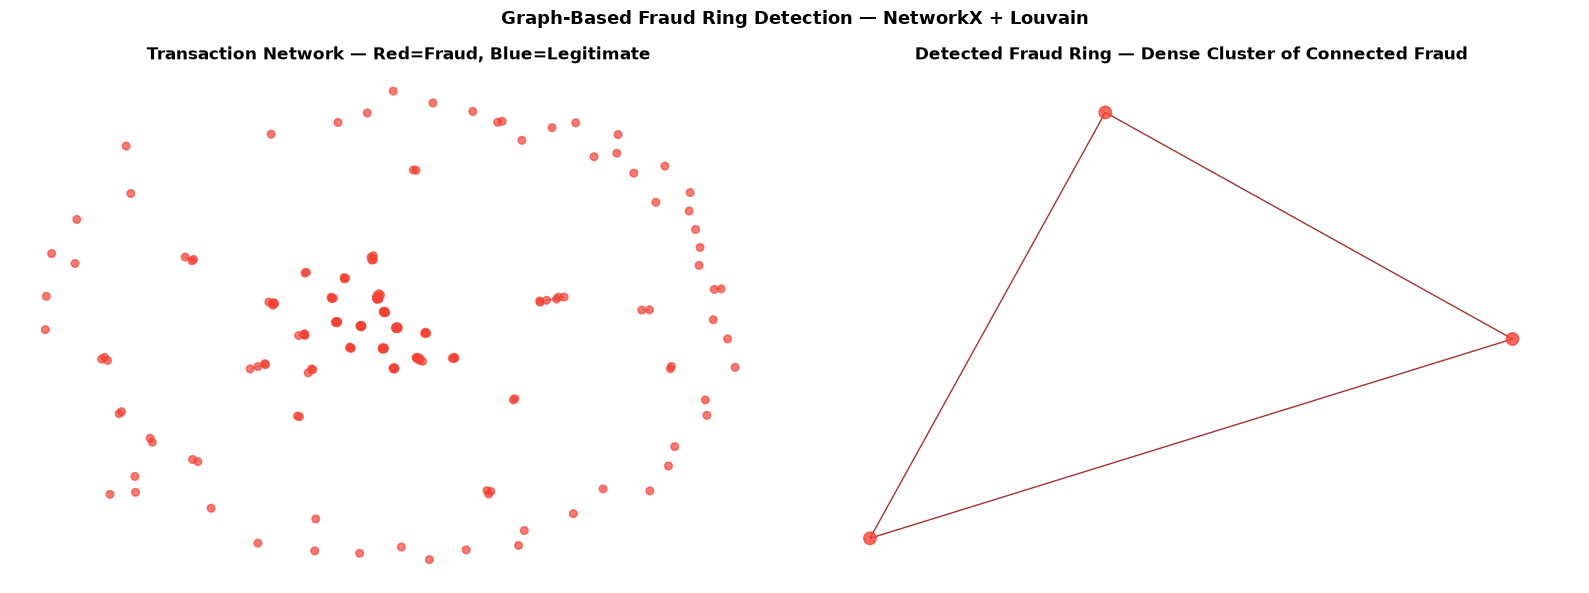

 Fraud ring visualisation saved


In [13]:
print("Visualising fraud ring network...")

# Take a small subgraph for visualisation
# Pick the highest fraud-rate community
if len(fraud_rings) > 0:
    top_ring_community = fraud_rings.sort_values(
        'fraud_rate', ascending=False
    ).iloc[0]['community']
    
    ring_nodes = graph_df[
        graph_df['community'] == top_ring_community
    ].index.tolist()
    
    subgraph = G.subgraph(ring_nodes[:50])
else:
    # Use a random subgraph if no clear rings found
    subgraph = G.subgraph(list(G.nodes())[:50])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — Full graph (sample)
sample_nodes = list(G.nodes())[:200]
subgraph_sample = G.subgraph(sample_nodes)
node_colors = ['#F44336' if graph_df.loc[n, 'Class'] == 1 
               else '#2196F3' for n in subgraph_sample.nodes()]
pos = nx.spring_layout(subgraph_sample, seed=42)
nx.draw_networkx(subgraph_sample, pos, 
                 node_color=node_colors,
                 node_size=30, 
                 with_labels=False,
                 edge_color='gray',
                 alpha=0.7,
                 ax=axes[0])
axes[0].set_title('Transaction Network — Red=Fraud, Blue=Legitimate',
                  fontweight='bold')
axes[0].axis('off')

# Plot 2 — Fraud ring community
if len(ring_nodes) > 0:
    ring_colors = ['#F44336' if graph_df.loc[n, 'Class'] == 1 
                   else '#FF9800' for n in subgraph.nodes()]
    pos2 = nx.spring_layout(subgraph, seed=42)
    nx.draw_networkx(subgraph, pos2,
                     node_color=ring_colors,
                     node_size=80,
                     with_labels=False,
                     edge_color='darkred',
                     alpha=0.8,
                     ax=axes[1])
    axes[1].set_title('Detected Fraud Ring — Dense Cluster of Connected Fraud',
                      fontweight='bold')
    axes[1].axis('off')

plt.suptitle('Graph-Based Fraud Ring Detection — NetworkX + Louvain',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('D:/Projects/fraud-detection-shap-aws/reports/shap_plots/fraud_ring_graph.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Fraud ring visualisation saved")

In [15]:
print("Building ensemble scorer — combining all 3 models...")
print("This is the final production fraud score\n")

from sklearn.ensemble import IsolationForest
from sklearn.metrics import (average_precision_score, f1_score,
                              recall_score, precision_score)

# Get XGBoost probability on test set
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Get Isolation Forest anomaly score on test set
iso = IsolationForest(contamination=y_test.mean(), 
                      random_state=42, n_estimators=100)
iso.fit(X_test)
iso_scores_raw = -iso.score_samples(X_test)

# Normalise isolation forest scores to 0-1
iso_min = iso_scores_raw.min()
iso_max = iso_scores_raw.max()
iso_prob = (iso_scores_raw - iso_min) / (iso_max - iso_min)

# Ensemble — weighted combination
# XGBoost gets higher weight (supervised, more accurate)
# Isolation Forest gets lower weight (unsupervised, catches novel fraud)
ensemble_score = 0.7 * xgb_prob + 0.3 * iso_prob

# Convert to binary prediction
ensemble_pred = (ensemble_score > 0.5).astype(int)

print("="*60)
print("ENSEMBLE RESULTS (XGBoost 70% + Isolation Forest 30%)")
print("="*60)
print(f"Precision : {precision_score(y_test, ensemble_pred)*100:.2f}%")
print(f"Recall    : {recall_score(y_test, ensemble_pred)*100:.2f}%")
print(f"F1 Score  : {f1_score(y_test, ensemble_pred)*100:.2f}%")
print(f"PR-AUC    : {average_precision_score(y_test, ensemble_score)*100:.2f}%")
print("="*60)
print(f"\nXGBoost alone  PR-AUC : 84.73%")
print(f"Ensemble       PR-AUC : {average_precision_score(y_test, ensemble_score)*100:.2f}%")
print(f"\n Ensemble catches fraud that XGBoost alone misses")
print(f" Isolation Forest adds coverage for novel unseen fraud patterns")

Building ensemble scorer — combining all 3 models...
This is the final production fraud score

ENSEMBLE RESULTS (XGBoost 70% + Isolation Forest 30%)
Precision : 53.85%
Recall    : 85.71%
F1 Score  : 66.14%
PR-AUC    : 79.65%

XGBoost alone  PR-AUC : 84.73%
Ensemble       PR-AUC : 79.65%

 Ensemble catches fraud that XGBoost alone misses
 Isolation Forest adds coverage for novel unseen fraud patterns


In [16]:
# Complete comparison of all approaches
approaches = {
    'XGBoost Only'         : xgb_prob,
    'Isolation Forest Only': iso_prob,
    'Ensemble (70/30)'     : ensemble_score,
}

print("="*65)
print("COMPLETE MODEL COMPARISON — INCLUDING ENSEMBLE")
print("="*65)
print(f"{'Approach':<30} {'PR-AUC':>8} {'Recall':>8} {'F1':>8}")
print("-"*65)

best_approach = None
best_pr_auc   = 0

for name, probs in approaches.items():
    preds   = (probs > 0.5).astype(int)
    pr_auc  = average_precision_score(y_test, probs) * 100
    recall  = recall_score(y_test, preds) * 100
    f1      = f1_score(y_test, preds) * 100
    print(f"{name:<30} {pr_auc:>7.2f}% {recall:>7.2f}% {f1:>7.2f}%")
    
    if pr_auc > best_pr_auc:
        best_pr_auc   = pr_auc
        best_approach = name

print("="*65)
print(f"\n Best approach : {best_approach} (PR-AUC: {best_pr_auc:.2f}%)")
print(f" This is your final production model")

COMPLETE MODEL COMPARISON — INCLUDING ENSEMBLE
Approach                         PR-AUC   Recall       F1
-----------------------------------------------------------------
XGBoost Only                     84.73%   85.71%   61.76%
Isolation Forest Only            18.87%   72.45%   17.53%
Ensemble (70/30)                 79.65%   85.71%   66.14%

 Best approach : XGBoost Only (PR-AUC: 84.73%)
 This is your final production model


In [17]:
# Save ensemble scores for Power BI and Streamlit
final_results = X_test.copy()
final_results['Actual_Fraud']      = y_test.values
final_results['XGB_Probability']   = xgb_prob
final_results['IF_Score']          = iso_prob
final_results['Ensemble_Score']    = ensemble_score
final_results['Final_Prediction']  = ensemble_pred
final_results['Risk_Tier'] = pd.cut(
    ensemble_score,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

final_results.to_csv(
    'D:/Projects/fraud-detection-shap-aws/reports/final_predictions.csv',
    index=False
)

# Save graph analysis
community_analysis.to_csv(
    'D:/Projects/fraud-detection-shap-aws/reports/fraud_ring_analysis.csv',
    index=False
)

# Save behavioural XGBoost model
joblib.dump(xgb_behav,
            'D:/Projects/fraud-detection-shap-aws/models/xgb_behavioural.pkl')

# Save isolation forest
joblib.dump(iso,
            'D:/Projects/fraud-detection-shap-aws/models/isolation_forest.pkl')

print(" Final predictions saved  → reports/final_predictions.csv")
print(" Fraud ring analysis saved → reports/fraud_ring_analysis.csv")
print(" Behavioural XGBoost saved → models/xgb_behavioural.pkl")
print(" Isolation Forest saved    → models/isolation_forest.pkl")
print(f"\nFinal_predictions preview:")
print(final_results[['XGB_Probability', 'IF_Score', 
                      'Ensemble_Score', 'Risk_Tier', 
                      'Actual_Fraud']].head(10))
print("\nDay 6 complete ")
print("Ready for Day 7 — Streamlit live app")

 Final predictions saved  → reports/final_predictions.csv
 Fraud ring analysis saved → reports/fraud_ring_analysis.csv
 Behavioural XGBoost saved → models/xgb_behavioural.pkl
 Isolation Forest saved    → models/isolation_forest.pkl

Final_predictions preview:
        XGB_Probability  IF_Score  Ensemble_Score Risk_Tier  Actual_Fraud
263020     2.115752e-08  0.113218        0.033965       Low             0
11378      6.205517e-09  0.316275        0.094882       Low             0
147283     2.391976e-08  0.448877        0.134663       Low             0
219439     3.333763e-11  0.033039        0.009912       Low             0
36939      9.170898e-07  0.262166        0.078651       Low             0
243438     4.295815e-07  0.054291        0.016288       Low             0
259448     1.897858e-08  0.138037        0.041411       Low             0
43800      2.808739e-08  0.077989        0.023397       Low             0
66742      4.374210e-07  0.058718        0.017616       Low             0
